## PARIS inverse modelling results

This notebook contains options to plot and compare results from different inverse models. These variables can all be investigated:

- Posterior and prior country fluxes, total from all sectors
- Posterior, prior and observed modelled total mole fractions
- Posterior and prior modelled baseline mole fractions
- Posterior and prior spatial fluxes

Future updates may include:

- Sector-level emissions
- Comparison between each model's country/region definition

### Notebook setup:

1. Edit the `data_dir` to point towards where the model output is.

2. Update the `model_filenames` dictionary to point towards the experiment/model you want to plot. Update the `model_labels` and `model_colors` dictionaries, these change how each model is labelled in the plots.

3. Run the cell below, before running any of the plotting code.

In [1]:
%load_ext autoreload
%autoreload 2
import PARIS_inversion_results as func

data_dir = '/home/h02/aramsden/results/multi_gas_MCMC/processed_output'

model_filenames = {
'rhime':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized',
'rhime_13':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_13sites',
'rhime_26':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_26sites',
'rhime_36':'RHIME_NAME_EUROPE_EDGAR_rhime_obs_rhime_baseline_optimized_36sites',
'rhime_FrFlat':'RHIME_NAME_EUROPE_EDGAR-FrFlat_rhime_obs_rhime_baseline_optimized_36sites',
'rhime_WetCHARTs':'RHIME_NAME_EUROPE_EDGAR-WetCHARTs_rhime_obs_rhime_baseline_optimized_36sites',

'elris':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_elris_baseline_optimized',
'elris_13':'ELRIS_NAME_EUROPE_EDGAR_std_13sites',
'elris_26':'ELRIS_NAME_EUROPE_EDGARandWETLANDS_std_26sites',
'elris_35':'ELRIS_NAME_EUROPE_EDGARandWETLANDS_std_35sites',
'elris_intemobs':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_elris_baseline_optimized',
'elris_intemobsbl':'ELRIS_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_fixed',
'elris_intembl':'ELRIS_NAME_EUROPE_EDGAR_elris_obs_intem_baseline_fixed',
'elris_flat':'ELRIS_NAME_EUROPE_FLAT_elris_obs_elris_baseline_optimized',

'intem':'InTEM_NAME_EUROPE_EDGAR_intem_obs_intem_baseline_optimized',
'intem_2':'InTEM_NAME_EUROPE_2sites',
'intem_14':'InTEM_NAME_EUROPE_14sites',
'intem_13':'InTEM_NAME_EUROPE_EDGAR_13sites_intem_obs_intem_baseline_optimized',
'intem_33':'InTEM_NAME_EUROPE_EDGAR_33sites_intem_obs_intem_baseline_optimized',
'intem_26':'InTEM_NAME_EUROPE_EDGAR_33sites_no_mountain_intem_obs_intem_baseline_optimized',
'intem_allobs':'InTEM_NAME_EUROPE_EDGAR_all_obs_intem_baseline_optimised',
'intem_flat':'InTEM_NAME_EUROPE_FLAT_intem_obs_intem_baseline_optimized',
'intem_flat_allobs':'InTEM_NAME_EUROPE_FLAT_all_obs_intem_baseline_optimized'}


model_labels = {
'rhime':'RHIME',
'rhime_13':'RHIME 13 sites',
'rhime_26':'RHIME 26 sites',
'rhime_36':'RHIME 31 sites, EDGAR',
'rhime_FrFlat':'RHIME 31 site, EDGAR - France prior flat',
'rhime_WetCHARTs':'RHIME 31 site, EDGAR + WetCHARTs',

'elris':'ELRIS',
'elris_13':'ELRIS 13 sites',
'elris_26':'ELRIS 26 sites, EDGAR + WetCHART',
'elris_33':'ELRIS 33 sites',
'elris_35':'ELRIS 35 sites, EDGAR + WetCHART',
'elris_intemobs':'ELRIS intem obs',
'elris_intemobsbl':'ELRIS intem obs/baseline',
'elris_intembl':'ELRIS intem baseline',
'elris_flat':'ELRIS flat',

'intem':'InTEM',
'intem_2':'InTEM 2 site 2-yearly',
'intem_14':'InTEM 14 site monthly',
'intem_13':'InTEM 13 sites',
'intem_26':'InTEM 26 sites',
'intem_33':'InTEM 33 sites',
'intem_allobs':'InTEM all obs',
'intem_flat':'InTEM flat',
'intem_flat_allobs':'InTEM flat all obs'}

experiments = {
    '13':['rhime_13','intem_13','elris_13'],
    '26':['rhime_26','intem_26','elris_26'],
    '33':['rhime_WetCHARTs','intem_33','elris_35'],
    'prior':['rhime_FrFlat','rhime_WetCHARTs','rhime_36'],
    'r':['rhime_13','rhime_26','rhime_36'],
    'i':['intem_13','intem_26','intem_33'],
    'e':['elris_26','elris_35']}

NOTE: If plotting units or scales look odd, edit species_info.json to fix this.


### 1. Timeseries of country/region fluxes

##### Edit and run this cell to choose inputs:

In [ ]:
###################################
### edit variables in this block
species = 'ch4'
models = ['intem_2','intem_14'] #experiments['33']
period_override = ['other','monthly'] # ['monthly',]*3  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '1990-01-01' #inclusive
end_date = '2023-01-01' #not inclusive
model_colors = func.set_model_colors(models) # Get models color from models. Not very flexible and representative of exp not with CH4..
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]

#### Timeseries of country fluxes:

In [ ]:
###################################
### edit variables in this block
plot_regions = ['IRELAND','UK','FRANCE','GERMANY','BENELUX','NW_EU2'] #works best with 6 countries but can run with any number (will always create at least 4 subplots though)
plot_inventory = True
inventory_years = None #If None, plots most recent. Or can choose list of years: ['2022','2023']
fix_y_axes = False #if True: all y axis limits are the same, if False: each y axis is relative to the data
                     #if a list of floats (e.g. [0,0.1]) applies these limit to all axes
add_prior_unc = False #if True: plots prior uncertainty as shaded area
set_global_leg = True #If True, plots one single legend instead of one legend per subplot.
country_codes_as_titles = False #If True, lists 3-letter country codes under region names in subplot titles
plot_separate = True #If True, includes all model results as separate lines
plot_combined = False #If True, combined results, averaged from all models
plot_separate_by_year = True #If True, plot average flux over each year
period_override = None #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

fig = func.plot_country_flux(ds_all_flux_scaled,species,plot_regions,model_labels,
                             model_colors,
                             plot_inventory,inventory_years,data_dir,fix_y_axes,
                             add_prior_unc,set_global_leg,country_codes_as_titles=country_codes_as_titles,
                             plot_separate=plot_separate,plot_combined=plot_combined,
                             plot_separate_by_year=plot_separate_by_year,period_override=period_override)

Save plot here:

In [ ]:
#output_path = '/home/h02/aramsden/results/PARIS_results_comparison/fixed_baseline/InTEM_Feb2024_E-D_fixed_baseline_comparison_countryfluxes.png'

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 2. Modelled and observed mole fractions and/or baselines

##### Edit and run this cell to choose inputs and read in the data:

In [ ]:
###################################
### edit variables in this block
species = 'ch4' 
site = 'MHD'
models = ['intem_2','intem_14']#'rhime',]

period_override = ['other','monthly']  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
start_date = '2007-01-01' #inclusive
end_date = '2009-01-01'   #not inclusive

baseline_site = None #'MHD', 'JFJ' or 'CMN'. If None, does not mask by baseline time
###################################

###################################
### options for variables to include in the functions below 
# Yobs                - total observed mole fraction
# uYobs_repeatability - observed repeatability mole fraction uncertainty
# uYobs_variability   - observed variability mole fraction uncertainty
# uYmod               - model mole fraction uncertainty
# uYtotal             - total mole fraction uncertainty
# Yapriori            - prior total mole fraction
# Yapost              - posterior total mole fraction
# YaprioriBC          - prior baseline
# YapostBC            - posterior baseline
# Ybias               - posterior bias added to site
# YaprioriOuter       - prior mole fractions only from outer regions
# YapostOuter         - posterior mole fractions only from outer regions
###################################


ds_all_mf = func.read_mf(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_mf_sliced = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site,baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

In [ ]:
fig = func.plot_sites_timeseries(ds_all_mf,'Yapost',start_date,end_date,model_labels,model_colors)

#### Timeseries plot, separated by model:

In [ ]:
fig = func.plot_obs_modelled_separate(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yobs','Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

###################################
### Instructions for timeseries plotting: 
# - Add variables that you want to plot in "include"
# - To plot the histogram of the variables in "include", leave "diff_include" empty
# - To plot the histogram of Obs-variable, add the desired variable to be subtracted in "diff_include" (default value of "diff_include" = Yapost)
# - To erase uncertainty bars around the mean values of Yobs and Yapost set "add_unc" to False (default value of "add_unc" = True)
# - To choose y axis limits set y_lim=[min_value,max_value]
###################################

#### Timeseries plot, all models together:

In [ ]:
fig = func.plot_obs_modelled_together(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Absolute differences between two models:

In [ ]:
fig = func.plot_obs_diff(ds_all_mf_sliced,species,site,model_labels,
                                      model_colors,
                             include=['Yapost'],
                             diff_include=['Yapost'],
                             y_lim=None)

#### Calculate and plot stats for the fit to obs:

In [ ]:
ds_all_allsites = func.slice_mf(ds_all_mf.copy(),start_date,end_date,site=None,
                              baseline_site=baseline_site,
                              data_dir=data_dir,
                              scale_units=True,species=species)

pearson,nrmse = func.stats_mf(ds_all_allsites)

fig = func.plot_stats_mf(pearson,nrmse,species,model_labels,
                         model_colors,
                  start_date=start_date,end_date=end_date)

Save plot:

In [ ]:
output_path = None

#fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 3. Posterior country fluxes - lat lon grid prior and posterior comparison

##### Edit this cell to choose inputs:

In [2]:
###################################
### edit variables in this block
species = 'ch4'
start_date = '2020-01-01' #select the time period to plot (a month or year, depending on the inversion period)
end_date = '2025-01-01' #if end_date doesn't = start_date, a mean average of the whole period will be plotted
models = ['intem_14']#,'rhime','elris_name']
period_override = ['monthly']  #use to override standard inversion periods, must be a list the same length as models, e.g. ['monthly','yearly']
###################################

ds_all_flux = func.read_flux(data_dir,species,models,model_filenames,period_override=period_override)

ds_all_flux_scaled = {}

for m in models:
    ds_all_flux_scaled[m] = func.slice_flux({m:ds_all_flux[m]},start_date,end_date,scale_units=True,
                                species=species)[m]


Attempting to read data from intem_14
Reading data from: /home/h02/aramsden/results/multi_gas_MCMC/processed_output/InTEM/ch4/InTEM_NAME_EUROPE_14sites_ch4_monthly.nc
Done!

Masking data from intem_14
Scaling intem_14 units by 1000000000.0


##### Prior and posterior fluxes for all models:

In [ ]:
###################################
### edit variables in this block
plot_area = 'NWEU' #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'OrRd'   #Greens
cmap_diff = 'coolwarm'
c_border = 'dimgrey'    #country boundary colour
plot_site_locations = True #If True, adds markers to plots at locations of obs sites 
plot_point_markers = None #['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux(ds_all_flux_scaled,species,plot_area,model_labels,
                             cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                             period_override=period_override,plot_site_locations=plot_site_locations,
                             plot_point_markers=plot_point_markers,
                             season=None)

##### Directly compare posterior fluxes from two models:

In [ ]:
fig = func.plot_spatial_flux_comparison(ds_all_flux_scaled,species,plot_area,model_labels,
                                        cmap=cmap,cmap_diff=cmap_diff,c_border=c_border,
                                        period_override=period_override,
                                        plot_site_locations=plot_site_locations,
                                        plot_point_markers=plot_point_markers)

##### Plot prior, posterior or difference fluxes per time interval:

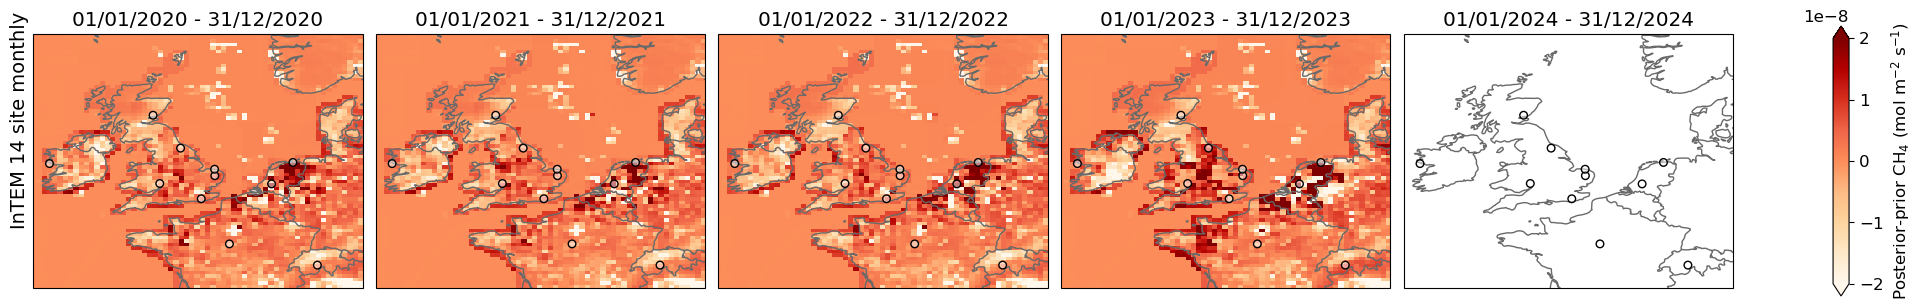

In [5]:
###################################
### edit variables in this block
plot_area = 'NWEU'   #options for: UK, FRANCE, GERMANY, ITALY, SWITZERLAND, NWEU, CWEU, EUROPE
cmap = 'OrRd'    #flux colour (e.g. 'viridis', 'coolwarm')
c_border = 'dimgrey' #country boundary colour (e.g. 'floralwhite', 'dimgrey')
#chop_by = ['1990-01-01','1991-01-01','1992-01-01','1993-01-01','1994-01-01']
#chop_by = ['1995-01-01','1996-01-01','1997-01-01','1998-01-01','1999-01-01']
#chop_by = ['2000-01-01','2001-01-01','2002-01-01','2003-01-01','2004-01-01']
#chop_by = ['2005-01-01','2006-01-01','2007-01-01','2008-01-01','2009-01-01']
#chop_by = ['2010-01-01','2011-01-01','2012-01-01','2013-01-01','2014-01-01']
#chop_by = ['2015-01-01','2016-01-01','2017-01-01','2018-01-01','2019-01-01']
chop_by = ['2020-01-01','2021-01-01','2022-01-01','2023-01-01','2024-01-01']
#chop_by = 'month'
#chop_by = 'year'
                    #time unit of the averaging period (options for 'year', 'month' and 'season')
                     #alternatively, a list of starting dates can be provided (format '2018-01-01')
dt = 1 #[[1,2,12],[3,4,5],[6,7,8],[9,10,11]]               #number of time steps (in chop_by units) to use in the averaging
                     #if chop_by='season': set dt to a list of lists with the months to use in the average (e.g. dt=[[1,2],[10,11]], will average over Jan-Feb and Oct-Nov)
var = 'posterior_prior_diff'  #variable to be plotted.
                              #options for: 'flux_total_posterior', 'flux_total_prior', 'posterior_prior_diff'
plot_site_locations = True #If True, adds markers to plots at locations of obs sites
plot_point_markers = None #['paris','london'] #plot a marker at these locations, options for 'paris', 'london', 'nw_england' (PFC-218 source) or any value [lon,lat]
###################################

fig = func.plot_spatial_flux_per_timestamp(ds_all_flux_scaled,species,plot_area,model_labels,end_date,
                                            cmap=cmap,c_border=c_border,
                                            var=var,chop_by=chop_by,dt=dt,period_override=period_override,
                                            plot_site_locations=plot_site_locations,
                                            plot_point_markers=plot_point_markers)

In [ ]:
output_path = '/home/h02/aramsden/results/intem_sector_ch4/spatial_fluxes/InTEM_14site_monthly_spatial_ch4_2020_2023.png'

fig.savefig(output_path,bbox_inches='tight',pad_inches=0.2,dpi=300)

### 7. Compare region definitions

THIS NEEDS UPDATING TO COMPARE MULTIPLE MODELS - CURRENTLY THESE NEED TO BE INPUT MANUALLY

In [ ]:
species = 'ch4' #select the species you want to plot
plot_region = 'UK' #choose the region mask to plot

In [ ]:
# Read in emissions output

intem = xr.open_dataset(os.path.join(data_dir,f'InTEM_NAME_EUROPE_{intem_species[species]}_{period[m][species]}.nc'))
#rhime = xr.open_dataset(os.path.join(data_dir,f'RHIME_NAME_EUROPE_{species}_{period}.nc'))
#empa = xr.open_dataset(os.path.join(data_dir,f'{empa_name}_FLEXPART_EUROPE_{species}_{period}.nc')) 

try:
    intem_r0 = np.where(intem['countrynames'].values == plot_region)[0][0]
except:
    print(f'No region in InTEM called {plot_region}')

In [ ]:
ax_limits = [-12,25,40,65] #min_lon, max_lon, min_lat, max_lat

fig,ax = plt.subplots(2,3,figsize=(12,6),constrained_layout=True,
                          subplot_kw={'projection':cartopy.crs.PlateCarree()})

for i in range(2):
    for j in range(3):
        ax[i,j].add_feature(cartopy.feature.BORDERS,linestyle=':',edgecolor='black',linewidth=1.)
        ax[i,j].coastlines(resolution='50m',color='black',linewidth=1.)
        ax[i,j].set_extent(ax_limits)
        
#plot intem
ax[0,0].pcolormesh(intem.lon.values,intem.lat.values,intem['region_definitions'][:,:,intem_r0],cmap='Blues',
                 vmin=0,vmax=2)
ax[0,0].set_title(f'InTEM {plot_region} mask')

#plot difference
#ax[1,0].pcolormesh(intem.lon.values,intem.lat.values,
#                   intem['region_definitions'][:,:,intem_r0]-rhime['region_definitions'][:,:,rhime_r0],
#                   cmap='bwr')
ax[1,0].set_title(f'InTEM {plot_region} - RHIME {plot_region}')